# Which effect did the openmp Bug have on? (on surface variables)

experiments with openmp had artifacts. here we take a look how big the effect of the bug is on certain varibles

- data without openmp is taken from Daniel's exp010
- data with openmp is taken from Irene's experiments, for case 2 and 3 Irene did not record the 2d-surf variables. so only case 1 is considered for the comparison of surface variables here. (note: "cesar2-20240928-exp001ComIn" did record 2d_surf)
- since the radiation bug is most obvious for case 2 from the tripcolorplots, it would we nice to compare the surfvariables for case 2. so check out if "cesar2-20240928-exp001ComIn" is usefull here (did it, see below)

In [1]:
%matplotlib inline

# system libs
import os, sys, glob
import datetime

# array operators and netcdf datasets
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)

# plotting
import pylab as plt
import seaborn as sns
sns.set_context('talk')

import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%H:%M')

# to have tools to format time
sys.path.append( '/work/bb1224/2024_MS-COURSE/tools/analysis' )
from tools import convert_timevec

# drawing onto a map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

import warnings
warnings.simplefilter("ignore")

import matplotlib.pyplot as plt
import matplotlib.tri as tri

## Open datasets and format time

In [2]:
# Cases mit zugehörigen Runs
cases = {
    "20240806": {
        "openmp": "/work/bb1376/user/irene/icon-build/experiments/cesar1-20240806-exp007",
        "noopenmp": "/work/bb1376/user/daniel/icon-build/experiments/cesar1-20240806-exp010"
    },
    "20240928": {
        "openmp": "/work/bb1376/user/irene/icon-build/experiments/cesar2-20240928-exp001ComIn",
        "noopenmp": "/work/bb1376/user/daniel/icon-build/experiments/cesar2-20240928-exp010"
    },
    "20241110": {
        "openmp": "/work/bb1376/user/irene/icon-build/experiments/cesar3-20241110-exp001",
        "noopenmp": "/work/bb1376/user/daniel/icon-build/experiments/cesar3-20241110-exp010"
    }
}

In [3]:
'''
Bsp.Zugriff auf Daten:
2D-Daten: data2d["20240806"]["openmp"]["d3"]
3D-Daten: data3d["20240806"]["noopenmp"]["d1"]
Grid: grids["20240806"]["openmp"]["d3"]
'''

data2d = {}
grids = {}

for date, runs in cases.items():
    data2d[date] = {}
    grids[date] = {}
    for run_name, path in runs.items():
        # 2D- und 3D-Daten laden
        data2d[date][run_name] = {
            f"d{dom}": xr.open_mfdataset(f"{path}/2d_*_DOM0{dom}_ML_{date}T????00Z.nc")
            for dom in range(1, 4)
        }

        # Grid-Dateien laden
        grids[date][run_name] = {
            f"d{dom}": xr.open_dataset(f"{path}/domain{dom}_DOM0{dom}.nc")
            for dom in range(1, 4)
        }

In [4]:
#convert time
for date in data2d:
    for run in data2d[date]:
        for dom in data2d[date][run]:
            data2d[date][run][dom]['time'] = convert_timevec(data2d[date][run][dom].time.data)
            #data3d[date][run][dom]['time'] = convert_timevec(data3d[date][run][dom].time.data)

## tripcolor-Maps comparison for all 3 Cases

In [5]:
def plot_case_comparison_map(data2d, grids, case_date, dom="3", var="sod_t", time_str="15:00:00", run1="openmp", run2="noopenmp"):
    """
    Vergleicht zwei ICON-Runs in einem bestimmten Fall (Datum) anhand einer Variable zu einem Zeitpunkt.
    Zeigt drei Subplots: run1, run2, Differenz.
    
    Parameters:
    - data2d: dict[date][run][dom] → xarray.Dataset mit 2D-Daten
    - grids:  dict[date][run][dom] → xarray.Dataset mit Grid-Informationen
    - case_date: str, z. B. "20240928"
    - dom: str, Domain (z. B. "1", "2", "3")
    - var: str, Name der zu vergleichenden Variable (z. B. "sod_t")
    - time_str: str, Zeit in ISO-Format (z. B. "15:00:00")
    - run1/run2: str, Namen der zu vergleichenden Runs (z. B. "openmp", "noopenmp")
    """

    # Grid einmal laden (z. B. von run1 – beide sollten dieselbe Geometrie haben)
    grid = grids[case_date][run1][f"d{dom}"]
    voc = grid["vertex_of_cell"].T - 1  # ICON verwendet 1-basierte Indizes
    triang = tri.Triangulation(grid["vlon"], grid["vlat"], triangles=voc)

    # Zeitstempel auswählen
    t_sel = f"{case_date}T{time_str}"

    # Daten für beide Runs laden
    ds1 = data2d[case_date][run1][f"d{dom}"].sel(time=t_sel)
    ds2 = data2d[case_date][run2][f"d{dom}"].sel(time=t_sel)
    
    
    def eval_var(ds, expression):
        # Map alle Variablennamen im Ausdruck auf DataArrays
        local_vars = {v: ds[v] for v in ds.data_vars}
        return eval(expression, {}, local_vars)

    # Ausdruck auswerten
    v1 = eval_var(ds1, var)
    v2 = eval_var(ds2, var)
    vdiff = v1 - v2

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    for ax, data, title in zip(
        axs,
        [v1, v2, vdiff],
        [f"{run1}: {var}", f"{run2}: {var}", f"Difference ({run1} - {run2})"]
    ):
        pc = ax.tripcolor(triang, data, shading='flat')
        fig.colorbar(pc, ax=ax)
        ax.set_title(f"{title}\n{t_sel}")
        ax.tick_params(labelsize=9)
        
    plt.suptitle(f"{var} comparison – case {case_date}, DOM{dom}", fontsize=16)
    plt.show()


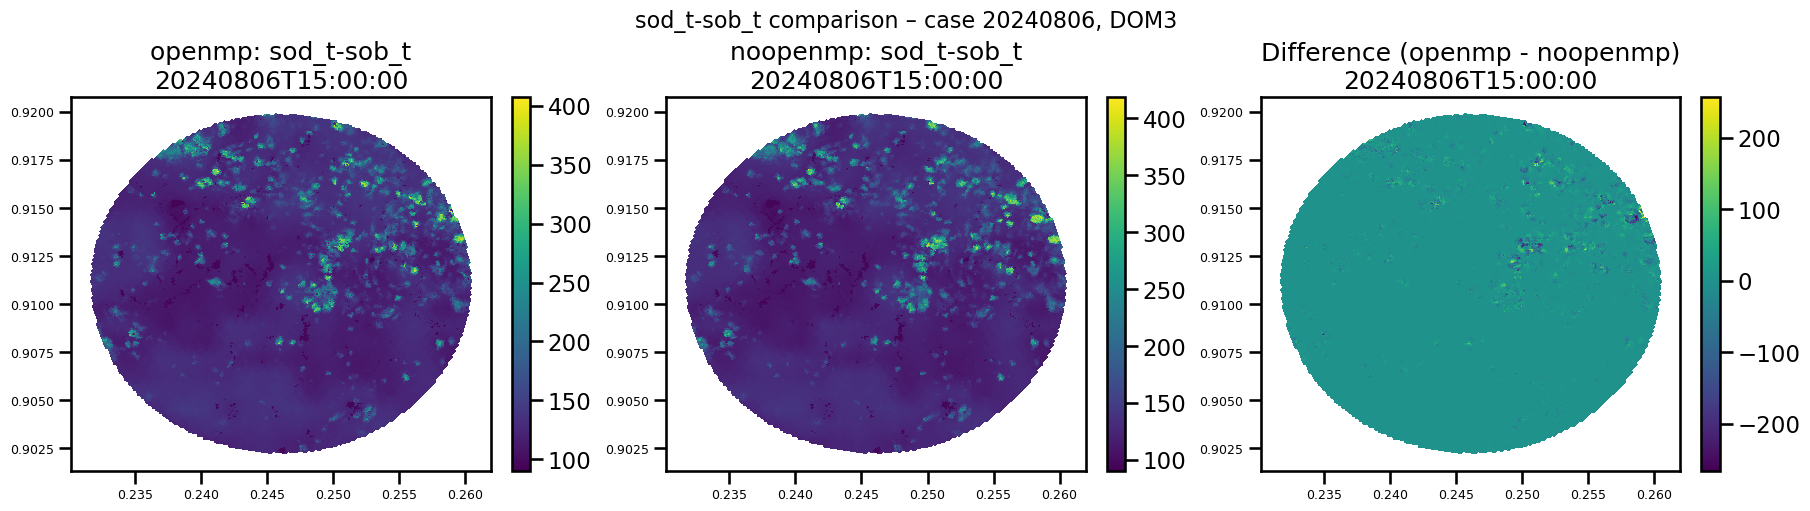

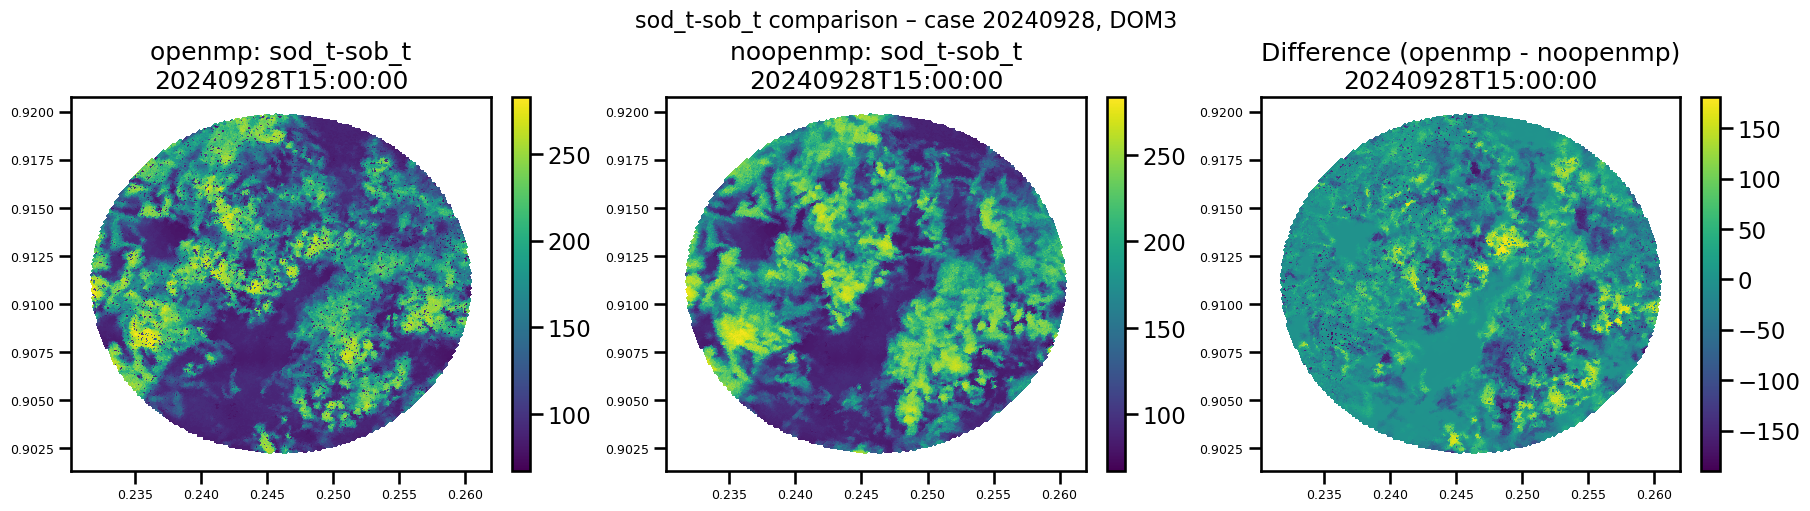

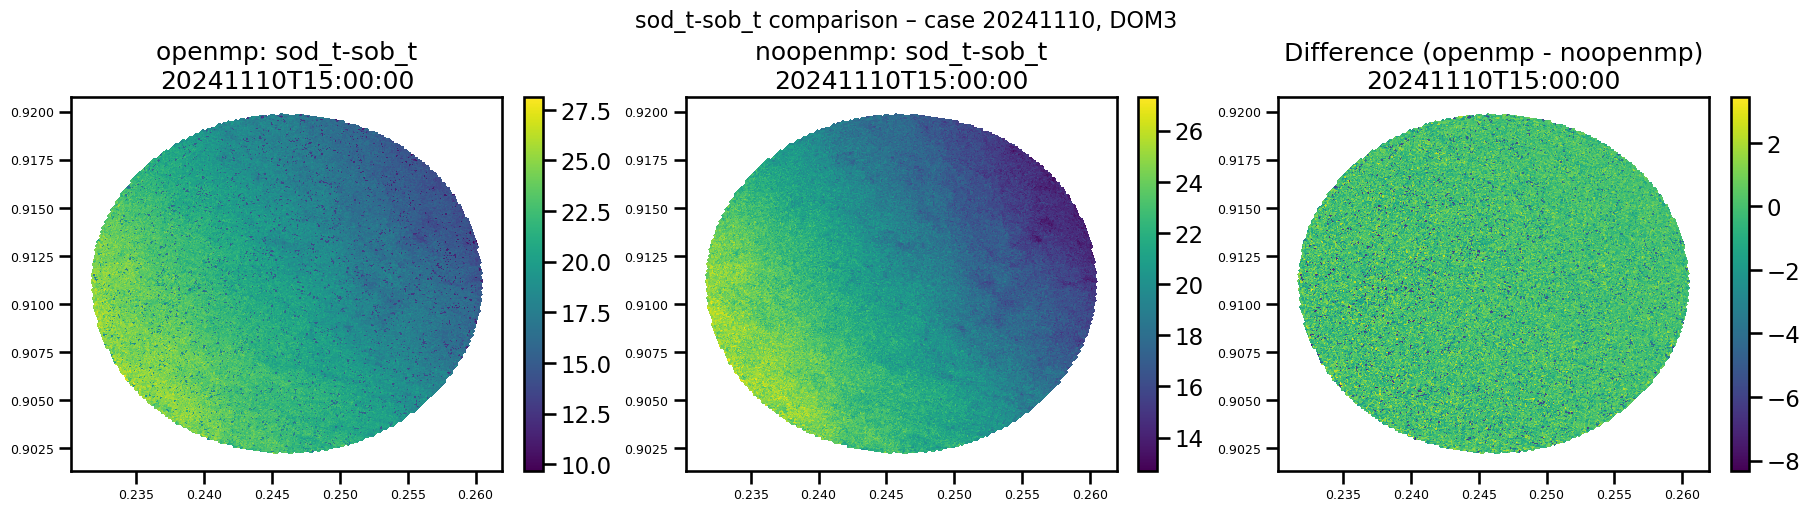

In [12]:
case_dates = ["20240806", "20240928", "20241110"]

for case_date in case_dates:
    plot_case_comparison_map(
        data2d=data2d,
        grids=grids,
        case_date=case_date,
        dom="3",
        var="sod_t-sob_t",
        time_str="15:00:00",
        run1="openmp",
        run2="noopenmp"
    )

## Variabel-Mean Timeseries

In [7]:
def plot_multiple_variable_comparisons(
    case_date: str,
    run1: str,
    run2: str,
    dom: str,
    variables: list,
    mean_dims: tuple = None,
    height_value: float = None
):
    """
    Plots time series of multiple variables from two ICON runs, with difference plots side-by-side.

    Parameters:
        case_date (str): e.g. "20240806"
        run1 (str): e.g. "openmp"
        run2 (str): e.g. "noopenmp"
        dom (str): e.g. "3"
        variables (list): list of variable names to compare
        mean_dims (tuple): optional tuple of dims to average over
        height_value (float): if variable has height dimension
    """

    d1 = data2d[case_date][run1][f"d{dom}"]
    d2 = data2d[case_date][run2][f"d{dom}"]

    def eval_var(ds, expression):
        local_vars = {v: ds[v] for v in ds.data_vars}
        return eval(expression, {}, local_vars)

    nvars = len(variables)
    fig, axs = plt.subplots(nrows=nvars, ncols=2, figsize=(14, 4 * nvars), sharex=True)

    if nvars == 1:
        axs = np.array([axs])  # Ensure 2D array for single variable

    for i, varname in enumerate(variables):
        v1 = eval_var(d1, varname)
        v2 = eval_var(d2, varname)

        if height_value is not None and "height" in v1.dims:
            v1 = v1.sel(height=height_value)
            v2 = v2.sel(height=height_value)

        dims = mean_dims or tuple(dim for dim in v1.dims if dim != "time")
        ts1 = v1.mean(dim=dims)
        ts2 = v2.mean(dim=dims)
        diff = ts1 - ts2

        # Left: time series of both runs
        ts1.plot(ax=axs[i, 0], label=run1)
        ts2.plot(ax=axs[i, 0], label=run2)
        axs[i, 0].set_title(f"{varname} over time")
        axs[i, 0].set_ylabel(varname)
        axs[i, 0].legend()
        axs[i, 0].grid(True)

        # Right: difference
        diff.plot(ax=axs[i, 1], label=f"{run1} - {run2}", color="purple")
        axs[i, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
        axs[i, 1].set_title(f"Difference: {run1} - {run2}")
        axs[i, 1].set_ylabel("Difference")
        axs[i, 1].legend()
        axs[i, 1].grid(True)

    axs[-1, 0].set_xlabel("Time")
    axs[-1, 1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()


## Compare Surface variables for case 1

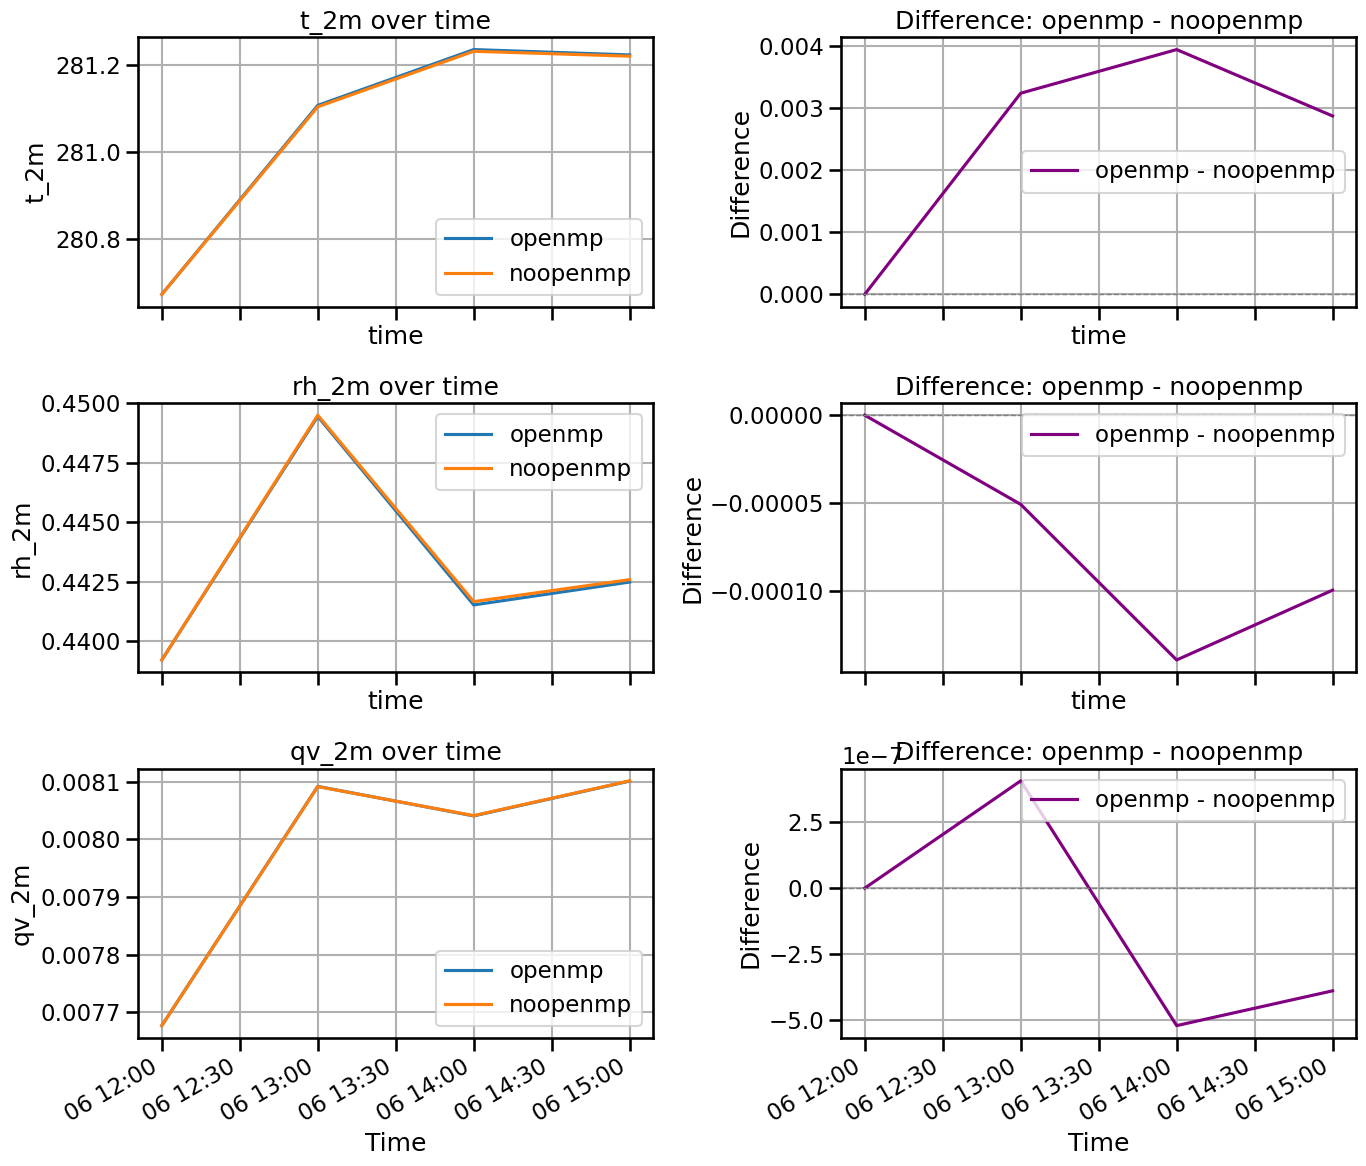

In [14]:
plot_multiple_variable_comparisons(
    case_date="20240806", #case1: 20240806 , case 2: 20240928 ,case3: 20241110 
    run1="openmp",
    run2="noopenmp",
    dom="1",
    variables=["t_2m", "rh_2m", "qv_2m"],
    height_value=2.0
)


## Compare Surface variables for case 2

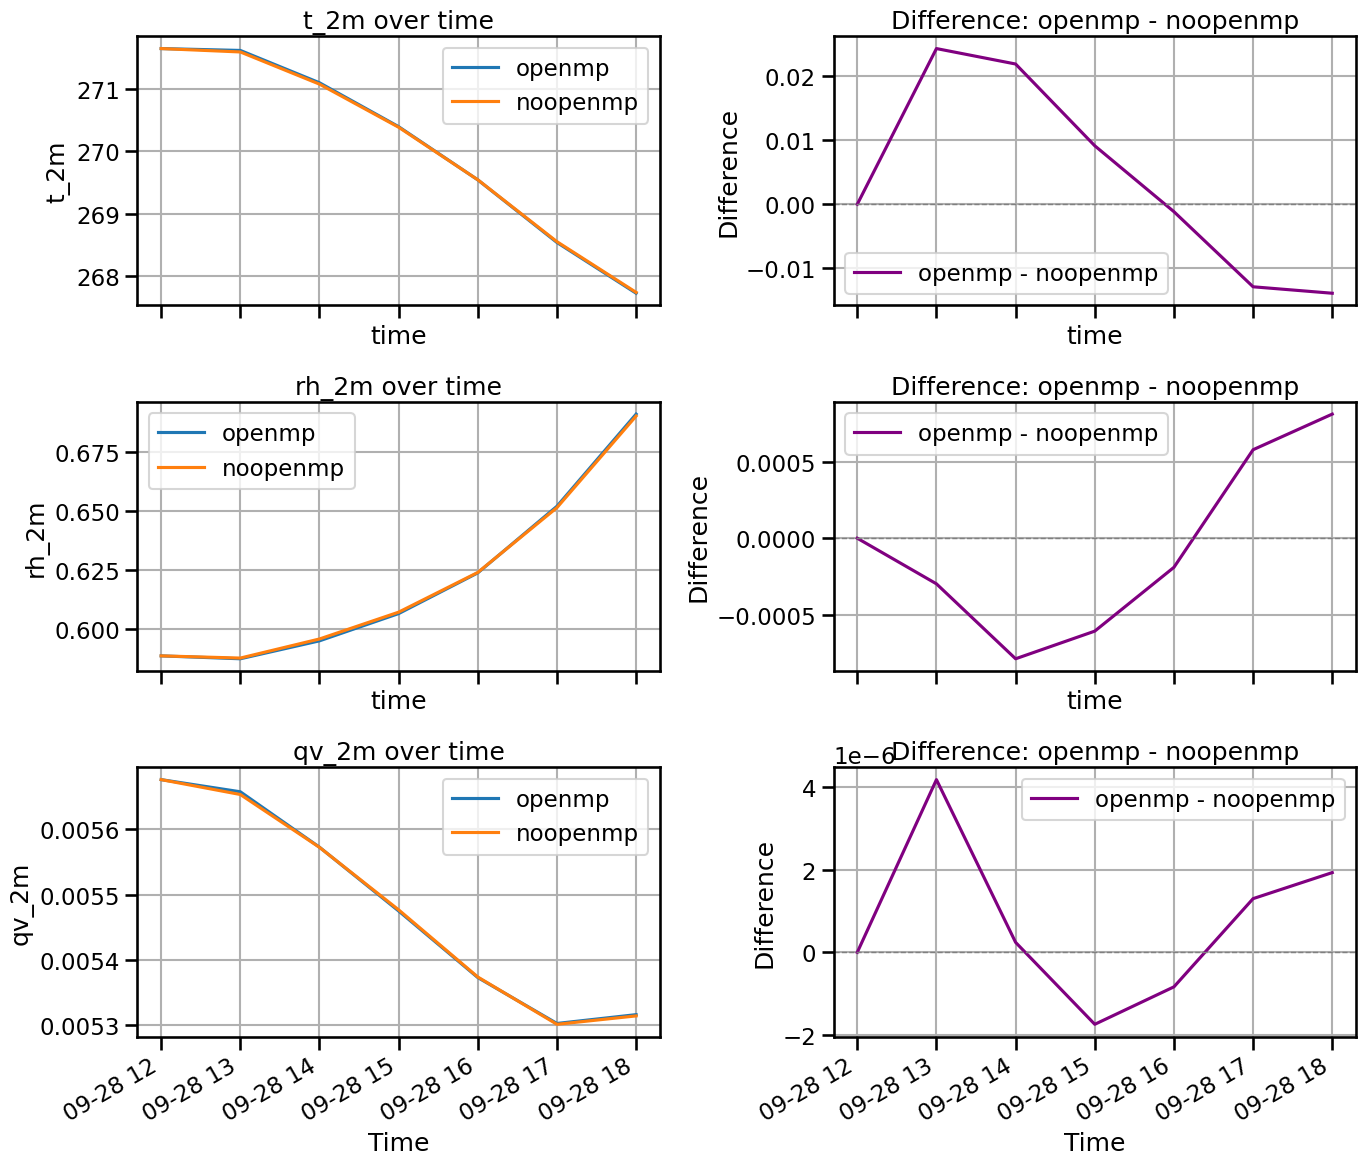

In [9]:
plot_multiple_variable_comparisons(
    case_date="20240928", #case1: 20240806 , case 2: 20240928 ,case3: 20241110 
    run1="openmp",
    run2="noopenmp",
    dom="1",
    variables=["t_2m", "rh_2m", "qv_2m"],
    height_value=2.0
)


## Compare Surface variables for case 3
For case 3 we have no 2d_surf variables from the openmp runs...

In [10]:
data2d['20240806']['noopenmp']['d1']

<xarray.Dataset>
Dimensions:        (time: 4, plev: 1, bnds: 2, plev_2: 1, plev_3: 1,
                    ncells: 142720, height: 1, height_2: 1, depth: 8,
                    depth_2: 9, depth_3: 1)
Coordinates:
  * time           (time) datetime64[ns] 2024-08-06T12:00:00 ... 2024-08-06T1...
  * plev           (plev) float64 0.0
  * plev_2         (plev_2) float64 400.0
  * plev_3         (plev_3) float64 800.0
  * height         (height) float64 2.0
  * height_2       (height_2) float64 10.0
  * depth          (depth) float64 5.0 20.0 60.0 ... 1.62e+03 4.86e+03 1.458e+04
  * depth_2        (depth_2) float64 0.0 5.0 20.0 ... 4.86e+03 1.458e+04
  * depth_3        (depth_3) float64 0.0
Dimensions without coordinates: bnds, ncells
Data variables: (12/48)
    plev_bnds      (time, plev, bnds) float64 dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    plev_2_bnds    (time, plev_2, bnds) float64 dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    plev_3_bnds    (time, plev_3, bnds) float64 dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    tqv_dia        (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    tqc_dia        (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    tqi_dia        (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    ...             ...
    sou_s          (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    thb_s          (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    thu_s          (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    sob_t          (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    sod_t          (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    thb_t          (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
Attributes:
    CDI:                  Climate Data Interface version 2.4.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  99
    uuidOfHGrid:          7fad9f84-2562-8608-875c-071c55c029c0
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2024.10; revision: icon-2024.10-public-0-g...
    history:              /home/b/b383413/workspace/icon-build/bin/icon at 20...
    references:           see MPIM/DWD publications
    comment:              Daniel Kloster (b383413) on l30567 (Linux 4.18.0-51...